# ICE Analytics - Product Activity Analysis


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt # modulo grafico 
import seaborn as sns # genera graficos estadisticos 
import warnings

warnings.filterwarnings('ignore') 
sns.set_style('whitegrid') # se configura el fondo blanco para crear el grafico 
plt.rcParams['figure.figsize'] = (10, 5) # tamaño por defecto para el grafico

df = pd.read_csv('product_activity.csv')
raw_rows = len(df) 
print(f"Dataset cargado: {df.shape[0]} filas x {df.shape[1]} columnas")
#  muestra dimensiones del dataset

Dataset cargado: 8782 filas x 12 columnas


## 1. Exploración Inicial (Medir antes de limpiar)

In [3]:
df.head(10) # muestra las primeras 10 filas, para saber los valores reales del data set 

,user_id,created_at,country,plan_type,user_age,post_id,post_category,post_created_at,votes_received,user_total_posts,days_since_signup,device_type
0,U01988,2025-02-18T02:07:44,PY,pro,26.0,P0008515,sport,2025-05-07T20:55:28,7,16,78,mobile
1,U00236,2025-06-22T07:49:10,BR,free,27.0,P0001023,tech,2025-09-13T20:31:06,1,9,83,web
2,U00791,2024-02-12T02:45:45,CL,free,28.0,P0003405,tech,2024-02-14T05:17:48,11,2,2,mobile
3,U01522,2024-09-22T07:06:50,US,free,16.0,P0006524,finance,2024-09-24T07:51:34,5,2,2,web
4,U01092,2025-07-18T02:27:52,PY,free,NaN,P0004665,education,2025-07-24T04:56:56,7,2,6,mobile
5,U00488,2025-03-19T16:56:05,US,free,43.0,P0002030,finance,2025-03-28T12:10:25,3,10,9,web
6,U00480,2024-07-29T02:09:07,US,free,26.0,P0002003,life,2024-08-27T10:38:58,5,6,29,web
7,U01863,2024-12-12T21:40:02,CL,free,31.0,P0008000,health,2025-02-02T21:09:32,5,5,52,mobile
8,U00819,2024-04-26T02:18:59,BR,free,26.0,P0003544,health,2024-07-28T05:48:12,1,29,93,mobile
9,U00880,2024-12-12T23:03:33,UY,free,32.0,P0003784,science,2024-12-19T17:52:17,7,2,7,mobile


In [4]:
df.info() # muestra columna, tipo de dato y cantidad 

<class 'pandas.DataFrame'>
RangeIndex: 8782 entries, 0 to 8781
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   user_id            8782 non-null   str    
 1   created_at         8782 non-null   str    
 2   country            8782 non-null   str    
 3   plan_type          8782 non-null   str    
 4   user_age           8028 non-null   float64
 5   post_id            8782 non-null   str    
 6   post_category      8782 non-null   str    
 7   post_created_at    8782 non-null   str    
 8   votes_received     8782 non-null   int64  
 9   user_total_posts   8782 non-null   int64  
 10  days_since_signup  8782 non-null   int64  
 11  device_type        8782 non-null   str    
dtypes: float64(1), int64(3), str(8)
memory usage: 823.4 KB


In [5]:
df.describe() # estadisticas para poder detectar rangos sospechozos 

,user_age,votes_received,user_total_posts,days_since_signup
count,8028.000000,8782.000000,8782.000000,8782.000000
mean,27.902591,6.918356,8.324186,29.479390
std,7.547052,5.127311,6.754906,36.819928
min,16.000000,0.000000,1.000000,0.000000
25%,22.000000,3.000000,4.000000,5.000000
50%,28.000000,6.000000,6.000000,17.000000
75%,33.000000,9.000000,11.000000,40.000000
max,58.000000,74.000000,39.000000,404.000000


In [6]:
# Conteo de nulos por columna
print("=== NULOS POR COLUMNA ===")
print(df.isnull().sum()) # para saber si es nulo o no (TRUE O FALSE ) 
print(f"\nTotal de filas con al menos un nulo: {df.isnull().any(axis=1).sum()}")
# axis en 1 (RECORRE FILAS HACIA LA DERECHA) para saber si hay algun nulo 


print(f"\n=== DUPLICADOS EXACTOS ===")
print(f"Filas duplicadas exactas: {df.duplicated().sum()}")

=== NULOS POR COLUMNA ===
user_id                0
created_at             0
country                0
plan_type              0
user_age             754
post_id                0
post_category          0
post_created_at        0
votes_received         0
user_total_posts       0
days_since_signup      0
device_type            0
dtype: int64

Total de filas con al menos un nulo: 754

=== DUPLICADOS EXACTOS ===
Filas duplicadas exactas: 172


# Valores únicos y frecuencias de columnas categóricas

In [7]:

print("=== PLAN_TYPE (valores únicos) ===")
print(df['plan_type'].value_counts())
print(f"\n=== POST_CATEGORY (valores únicos) ===")
print(df['post_category'].value_counts())
print(f"\n=== DEVICE_TYPE (valores únicos) ===")
print(df['device_type'].value_counts())

=== PLAN_TYPE (valores únicos) ===
plan_type
free            5978
pro             1460
enterprise       306
Free             208
 free            197
FREE             196
FreE             189
PRo               46
 pro              44
PRO               44
Pro               38
Pro               35
EnterPrise        13
ENTERPRISE        11
 enterprise        7
Enterprise         7
premium            1
vip                1
enterprise+        1
Name: count, dtype: int64

=== POST_CATEGORY (valores únicos) ===
post_category
tech           1187
life            913
sports          899
science         753
finance         739
gaming          727
music           614
health          601
education       592
travel          445
 tech            70
Tech             67
TECH             56
tehc             50
Life             46
Finance          44
 sport           42
sciense          42
gamming          40
 life            38
SPORTS           37
 finance         37
LIFE             36
Sports          

# Chequeos lógicos de fechas

In [8]:
# convertimos string a formato fecha, para que no de error 
df['created_at_dt'] = pd.to_datetime(df['created_at'], errors='coerce') 
df['post_created_at_dt'] = pd.to_datetime(df['post_created_at'], errors='coerce')

# Posts que ocurren antes del signup
posts_before_signup = (df['post_created_at_dt'] < df['created_at_dt']).sum()
print(f"Posts con fecha anterior al signup: {posts_before_signup}")

# Fechas no parseables
# (Nat) == not a time 
print(f"created_at no parseables (NaT): {df['created_at_dt'].isna().sum()}") # ISNA == a ISNULL devuelve True o False 
print(f"post_created_at no parseables (NaT): {df['post_created_at_dt'].isna().sum()}")

# Chequeo de days_since_signup
df['days_since_signup_calc'] = (df['post_created_at_dt'] - df['created_at_dt']).dt.days # obtengo solo los dias como entero 
mismatch = (df['days_since_signup_calc'] != df['days_since_signup']) & df['days_since_signup_calc'].notna() # devuelve True donde si hay valor 
print(f"\ndays_since_signup inconsistentes: {mismatch.sum()} de {len(df)} ({mismatch.mean()*100:.1f}%)") # calcula el porcentaje de filas 

# Muestra de mismatches
print("\nEjemplos de mismatches (original vs calculado):")
df[mismatch][['user_id', 'created_at', 'post_created_at', 'days_since_signup', 'days_since_signup_calc']].head(5)
# me muestra las 5 primeras filas con errores  

Posts con fecha anterior al signup: 100
created_at no parseables (NaT): 1
post_created_at no parseables (NaT): 1

days_since_signup inconsistentes: 4477 de 8782 (51.0%)

Ejemplos de mismatches (original vs calculado):


,user_id,created_at,post_created_at,days_since_signup,days_since_signup_calc
5,U00488,2025-03-19T16:56:05,2025-03-28T12:10:25,9,8.0
7,U01863,2024-12-12T21:40:02,2025-02-02T21:09:32,52,51.0
9,U00880,2024-12-12T23:03:33,2024-12-19T17:52:17,7,6.0
17,U01956,2025-02-19T10:47:45,2025-04-28T01:34:08,68,67.0
18,U01179,2024-08-28T23:29:24,2024-09-14T18:31:09,17,16.0


# Paso 1: Remover duplicados exactos

In [9]:

rows_before = len(df)
df = df.drop_duplicates()
dupes_removed = rows_before - len(df)
print(f"Duplicados removidos: {dupes_removed} | Filas restantes: {len(df)}")

Duplicados removidos: 172 | Filas restantes: 8610


# Paso 2: Normalización canónica 


In [10]:
# la version correcta 
canonical_maps = {
    'plan_type': {
        'free': 'free', 'pro': 'pro', 'enterprise': 'enterprise'
    },
    'post_category': {
        'tech': 'tech', 'life': 'life', 'sports': 'sports', 'science': 'science',
        'finance': 'finance', 'gaming': 'gaming', 'music': 'music', 'health': 'health',
        'education': 'education', 'travel': 'travel',
        # Typos conocidos
        'tehc': 'tech', 'sport': 'sports', 'sporst': 'sports', 'sp0rts': 'sports',
        'sciense': 'science', 'gamming': 'gaming', 'finanse': 'finance',
        'educatoin': 'education', 'healt': 'health', 'lfe': 'life',
        'trvael': 'travel', 'musc': 'music',
    },
    'device_type': {
        'web': 'web', 'mobile': 'mobile', 'phone': 'mobile', 'desktop': 'desktop'
    }
}

# limpia cada categoria y muestra resultado para comprobar que esta bien hecho 
for col, mapping in canonical_maps.items():
    df[f'{col}_clean'] = df[col].str.strip().str.lower().map(mapping) # con map (mapping) remplazo cada valor usando el diccionario 
    n_invalid = df[f'{col}_clean'].isna().sum() # si es nulo lo suma 
    print(f"{col}: {n_invalid} valores fuera de diccionario")
    if n_invalid > 0:
        # le paso el valor de la columna y luego cuento las veces que hay valor sucio y lo transformo a diccionario 
        print(f"  No mapeados: {df[df[f'{col}_clean'].isna()][col].value_counts().to_dict()}")
    print(f"  Distribución limpia: {df[f'{col}_clean'].value_counts().to_dict()}\n")

plan_type: 3 valores fuera de diccionario
  No mapeados: {'premium': 1, 'vip': 1, 'enterprise+': 1}
  Distribución limpia: {'free': 6637, 'pro': 1631, 'enterprise': 339}

post_category: 2 valores fuera de diccionario
  No mapeados: {'politics': 1, 'mistery': 1}
  Distribución limpia: {'tech': 1397, 'life': 1039, 'sports': 1028, 'science': 882, 'finance': 865, 'gaming': 844, 'education': 687, 'music': 685, 'health': 681, 'travel': 500}

device_type: 2 valores fuera de diccionario
  No mapeados: {'tablet': 1, 'console': 1}
  Distribución limpia: {'web': 4328, 'mobile': 3689, 'desktop': 591}



In [ ]:
# Recalcular days_since_signup sobre el DF sin duplicados 

# verificamos si esta bien los datos  
df['days_since_signup_calc'] = (df['post_created_at_dt'] - df['created_at_dt']).dt.days
mismatch_mask = (df['days_since_signup_calc'] != df['days_since_signup']) & df['days_since_signup_calc'].notna()
print(f"Mismatches days_since_signup: {mismatch_mask.sum()} de {len(df)} ({mismatch_mask.mean()*100:.1f}%)")
print("-> Se usará days_since_signup_calc (calculado) para todo el análisis.")

Mismatches days_since_signup: 4399 de 8610 (51.1%)
-> Se usará days_since_signup_calc (calculado) para todo el análisis.


# Quarantine - Separar filas con errores duros

In [ ]:

checks = [  # Quita la coma y espacio sobrante
    (df['post_created_at_dt'] < df['created_at_dt'], 'post_before_signup'),
    (df['created_at_dt'].isna(), 'created_at_not_parseable'),
    (df['post_created_at_dt'].isna(), 'post_created_at_not_parseable'),
    (df['plan_type_clean'].isna(), 'plan_type_invalid'),
    (df['post_category_clean'].isna(), 'post_category_invalid'),
    (df['device_type_clean'].isna(), 'device_type_invalid'),
]

# SI LA CONDICION ES TRUE EN UNA FILA, ESA FILA TIENE ERROR 
df['reason_code'] = ''
for mask, reason in checks:
    df.loc[mask, 'reason_code'] += reason + ', ' # modifico solo las filas donde es TRUE
df['reason_code'] = df['reason_code'].str.rstrip(', ') # Quita la coma y espacio sobrante

df_quarantine = df[df['reason_code'] != ''].copy() # error 
df_clean = df[df['reason_code'] == ''].copy()  #limpio 

print(f"Filas en quarantine: {len(df_quarantine)}")
print(f"Filas en dataset limpio (CORE): {len(df_clean)}")
print(f"\nRazones de quarantine:")
print(df_quarantine['reason_code'].value_counts())

Filas en quarantine: 102
Filas en dataset limpio (CORE): 8508

Razones de quarantine:
reason_code
post_before_signup                                               95
plan_type_invalid                                                 2
created_at_not_parseable                                          1
device_type_invalid                                               1
post_category_invalid                                             1
plan_type_invalid, post_category_invalid, device_type_invalid     1
post_created_at_not_parseable                                     1
Name: count, dtype: int64


##  Data Quality Report

In [13]:
# Data Quality Report
print(f"""{'='*50}
        DATA QUALITY REPORT
{'='*50}
Filas RAW (originales):            {raw_rows}
Duplicados exactos removidos:      {dupes_removed}
Filas después de dedup:            {len(df)}
Filas en Quarantine:               {len(df_quarantine)}
Filas CORE (limpias):              {len(df_clean)}
% Quarantine:                      {len(df_quarantine)/len(df)*100:.1f}%
% Mismatches en days_since_signup: {mismatch_mask.sum()/len(df)*100:.1f}%
{'='*50}""")

        DATA QUALITY REPORT
Filas RAW (originales):            8782
Duplicados exactos removidos:      172
Filas después de dedup:            8610
Filas en Quarantine:               102
Filas CORE (limpias):              8508
% Quarantine:                      1.2%
% Mismatches en days_since_signup: 51.1%


### 4.1 Distribuciones (Volumen)

Usuarios únicos por plan:
plan_type_clean
free          1546
pro            367
enterprise      82
Name: user_id, dtype: int64


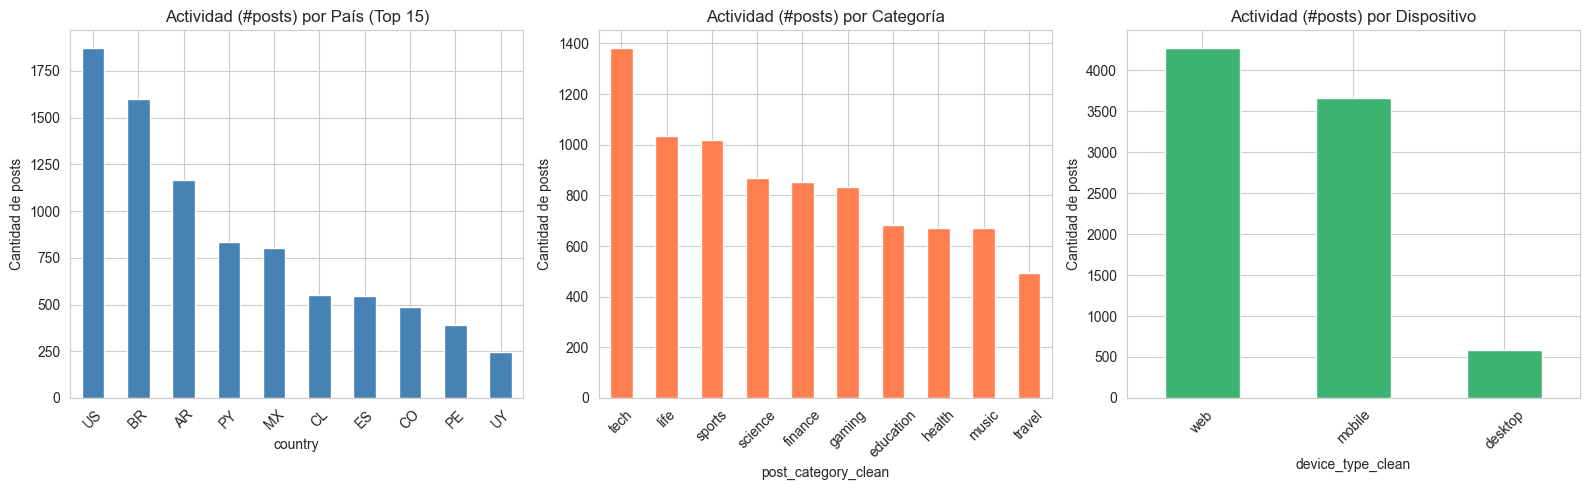

In [ ]:
# Usuarios únicos por plan
users_by_plan = df_clean.groupby('plan_type_clean')['user_id'].nunique().sort_values(ascending=False)
# agrupo todas las filas, cuenta con usuarios unicos y lo ordeno de mayor a menor 
print("Usuarios únicos por plan:")
print(users_by_plan)

fig, axes = plt.subplots(1, 3, figsize=(16, 5)) # 1 fila con 3 graficos con tamaño de 16x5

# axes[0], axes[1], axes[2] — Cada gráfico ocupa una posición.

# Posts por país
df_clean.groupby('country').size().sort_values(ascending=False).head(15).plot(
    kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Actividad (#posts) por País (Top 15)')
axes[0].set_ylabel('Cantidad de posts')
axes[0].tick_params(axis='x', rotation=45) # rota etiquetas para que se lean mejor 

# Posts por categoría
df_clean['post_category_clean'].value_counts().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Actividad (#posts) por Categoría')
axes[1].set_ylabel('Cantidad de posts') 
axes[1].tick_params(axis='x', rotation=45)

# Posts por dispositivo
df_clean['device_type_clean'].value_counts().plot(kind='bar', ax=axes[2], color='mediumseagreen')
axes[2].set_title('Actividad (#posts) por Dispositivo')
axes[2].set_ylabel('Cantidad de posts')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout() # ajusto el espaciado 
plt.show() # muestro los graficos 

### 4.2 Engagement (Votos)

Votos por Plan:
                 Media  Mediana   Std       N  P25   P75
plan_type_clean                                         
enterprise        7.57      7.0  4.90   333.0  4.0  10.0
free              6.69      6.0  5.03  6568.0  3.0   9.0
pro               7.65      7.0  5.49  1607.0  4.0  10.0


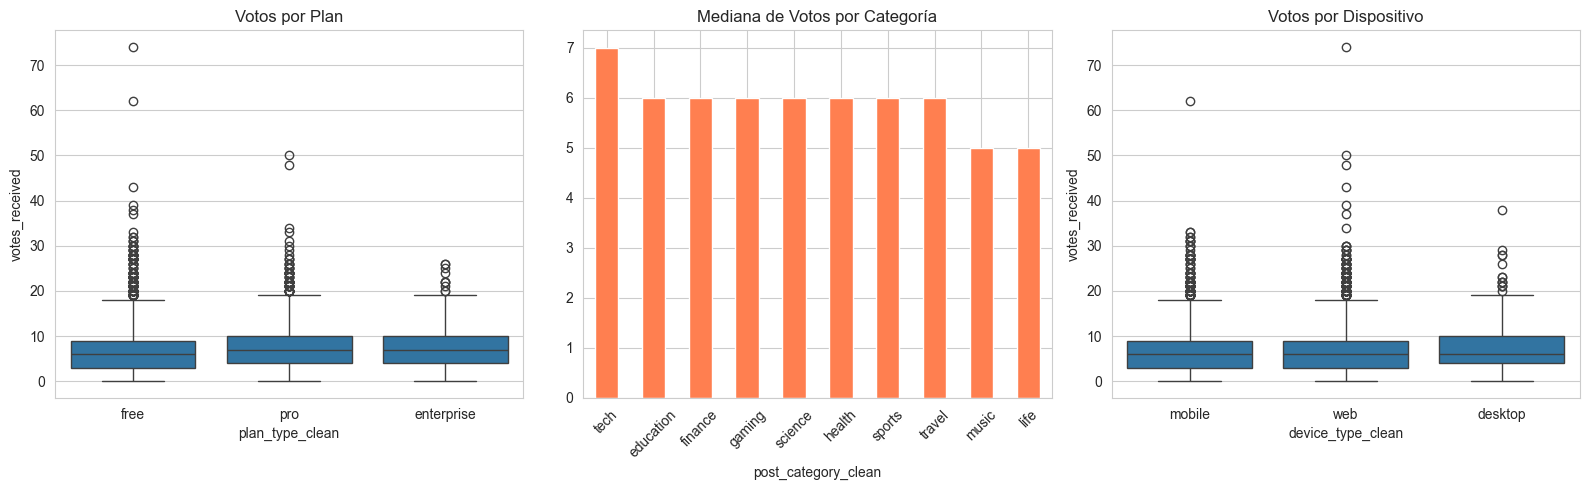

In [ ]:
# Votos por plan: media, mediana, percentiles
votes_by_plan = df_clean.groupby('plan_type_clean')['votes_received'].describe()[['mean', '50%', 'std', 'count', '25%', '75%']]
# genero estadisticas automaticamente 
votes_by_plan.columns = ['Media', 'Mediana', 'Std', 'N', 'P25', 'P75'] # remombro columnas para que se lean mejor 
print("Votos por Plan:")
print(votes_by_plan.round(2))

fig, axes = plt.subplots(1, 3, figsize=(16, 5)) # 1 fila con 3 graficos con tamaño de 16x5

# Gráfico de caja
sns.boxplot(data=df_clean, x='plan_type_clean', y='votes_received', ax=axes[0],
            order=['free', 'pro', 'enterprise'])
axes[0].set_title('Votos por Plan')

votes_by_cat = df_clean.groupby('post_category_clean')['votes_received'].median().sort_values(ascending=False) # ordena los valores
votes_by_cat.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Mediana de Votos por Categoría')
axes[1].tick_params(axis='x', rotation=45)

sns.boxplot(data=df_clean, x='device_type_clean', y='votes_received', ax=axes[2])
axes[2].set_title('Votos por Dispositivo')

plt.tight_layout() # ajusto el espaciado 
plt.show() # muestro los graficos 

Votos por País (Top 10 por volumen):
         Media  Mediana     N
country                      
US        6.97      6.0  1873
BR        6.89      6.0  1600
AR        6.77      6.0  1168
PY        6.60      6.0   837
MX        6.96      6.0   802
CL        7.31      6.0   552
ES        6.98      6.0   547
CO        7.32      6.0   488
PE        6.55      6.0   393
UY        6.76      6.0   248


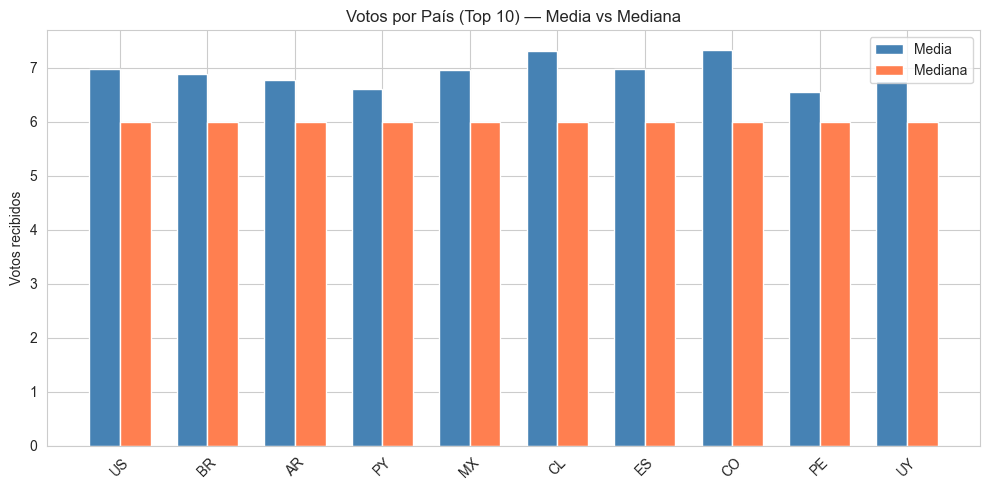

In [ ]:
# Votos por país (top 10 por volumen)
# agregamos funciones y ordenamos devuelta
votes_by_country = df_clean.groupby('country')['votes_received'].agg(['mean', 'median', 'count']).sort_values('count', ascending=False).head(10)
votes_by_country.columns = ['Media', 'Mediana', 'N']
print("Votos por País (Top 10 por volumen):")
print(votes_by_country.round(2))

fig, ax = plt.subplots(figsize=(10, 5)) # tamaño del grafico 
x = range(len(votes_by_country))
width = 0.35 # el ancho de cada barra 
ax.bar([i - width/2 for i in x], votes_by_country['Media'], width, label='Media', color='steelblue')
ax.bar([i + width/2 for i in x], votes_by_country['Mediana'], width, label='Mediana', color='coral')
ax.set_xticks(list(x)) # se conviete a lista para que el formato lo acepte 
ax.set_xticklabels(votes_by_country.index, rotation=45) # pone los nombres en eje X 
ax.set_title('Votos por País (Top 10) — Media vs Mediana')
ax.set_ylabel('Votos recibidos')
ax.legend() # muestra los colores de cada uno 
plt.tight_layout() # ajusto del espaciado 
plt.show()

### 4.3 Promedios e Interpretación


In [ ]:
# Promedio de votos por plan
print("=== Promedio de votos por plan (a nivel de evento/fila) ===")
print(df_clean.groupby('plan_type_clean')['votes_received'].mean().round(2))
# hago la media de votos para cada plan 

# Posts por usuario (usando user_total_posts, deduplicando por user_id)
user_level = df_clean.drop_duplicates(subset='user_id')
print("\n=== Posts por usuario (media y mediana) ===")
# Calcula media y mediana de cuántos posts hace cada usuario.
print(f"Media:   {user_level['user_total_posts'].mean():.2f}") # con 2 decimales  
print(f"Mediana: {user_level['user_total_posts'].median():.0f}") # sin decimales 

print("\n=== Comparación Media vs Mediana de votos por plan ===")
comp = df_clean.groupby('plan_type_clean')['votes_received'].agg(['mean', 'median'])
comp.columns = ['Media', 'Mediana']

# calculo ambas y las diferencio, SI LA DIFERENCIA ES GRANDE SIGNIFICA QUE HAY OUTLIERS 
comp['Diferencia'] = comp['Media'] - comp['Mediana'] 
print(comp.round(2))
print("\n-> Si Media > Mediana, hay sesgo positivo (outliers altos inflando el promedio).")

=== Promedio de votos por plan (a nivel de evento/fila) ===
plan_type_clean
enterprise    7.57
free          6.69
pro           7.65
Name: votes_received, dtype: float64

=== Posts por usuario (media y mediana) ===
Media:   4.31
Mediana: 3

=== Comparación Media vs Mediana de votos por plan ===
                 Media  Mediana  Diferencia
plan_type_clean                            
enterprise        7.57      7.0        0.57
free              6.69      6.0        0.69
pro               7.65      7.0        0.65

-> Si Media > Mediana, hay sesgo positivo (outliers altos inflando el promedio).


## 4.4 Evento vs Usuario


In [ ]:
# Promedio de votos: nivel evento vs nivel usuario
avg_event = df_clean['votes_received'].mean() # promedio de las filas 
avg_user = df_clean.groupby('user_id')['votes_received'].mean().mean()
# calcula el promedio de votos por cada usuario y luego el promedio de esos promedios 
# ASI EVITO QUE LOS USUARIOS CON MUCHOS POST DISTORSIONEN EL NUMERO DE POST 
print(f"Promedio votos por FILA (evento): {avg_event:.2f}") 
print(f"Promedio votos por USUARIO:       {avg_user:.2f}") 
print(f"Diferencia:                       {avg_event - avg_user:.2f}")

Promedio votos por FILA (evento): 6.91
Promedio votos por USUARIO:       6.90
Diferencia:                       0.01


## 5. Concentración y Temporalidad

In [ ]:
# Concentración: ¿Qué % de posts/votos viene del top 1% de usuarios?
user_stats = df_clean.groupby('user_id').agg(
    total_posts=('post_id', 'count'),
    total_votes=('votes_received', 'sum')
).sort_values('total_posts', ascending=False) # ordeno los valores   

n_users = len(user_stats)
top_1pct = max(1, int(np.ceil(n_users * 0.01))) # garantizo un minimo de 1 usuario  

top_users = user_stats.head(top_1pct) # tomo los usuarios mas activos 

# calculo que porcentaje total representan los usuarios 
pct_posts_top1 = top_users['total_posts'].sum() / user_stats['total_posts'].sum() * 100
pct_votes_top1 = top_users['total_votes'].sum() / user_stats['total_votes'].sum() * 100

print(f"Total de usuarios únicos: {n_users}")
print(f"Top 1% de usuarios ({top_1pct} usuarios):")
print(f"  - Generan {pct_posts_top1:.1f}% de los posts")
print(f"  - Reciben {pct_votes_top1:.1f}% de los votos")
print(f"\nEsto indica {'alta' if pct_posts_top1 > 15 else 'baja'} concentración de actividad.")

Total de usuarios únicos: 1995
Top 1% de usuarios (20 usuarios):
  - Generan 6.0% de los posts
  - Reciben 6.0% de los votos

Esto indica baja concentración de actividad.


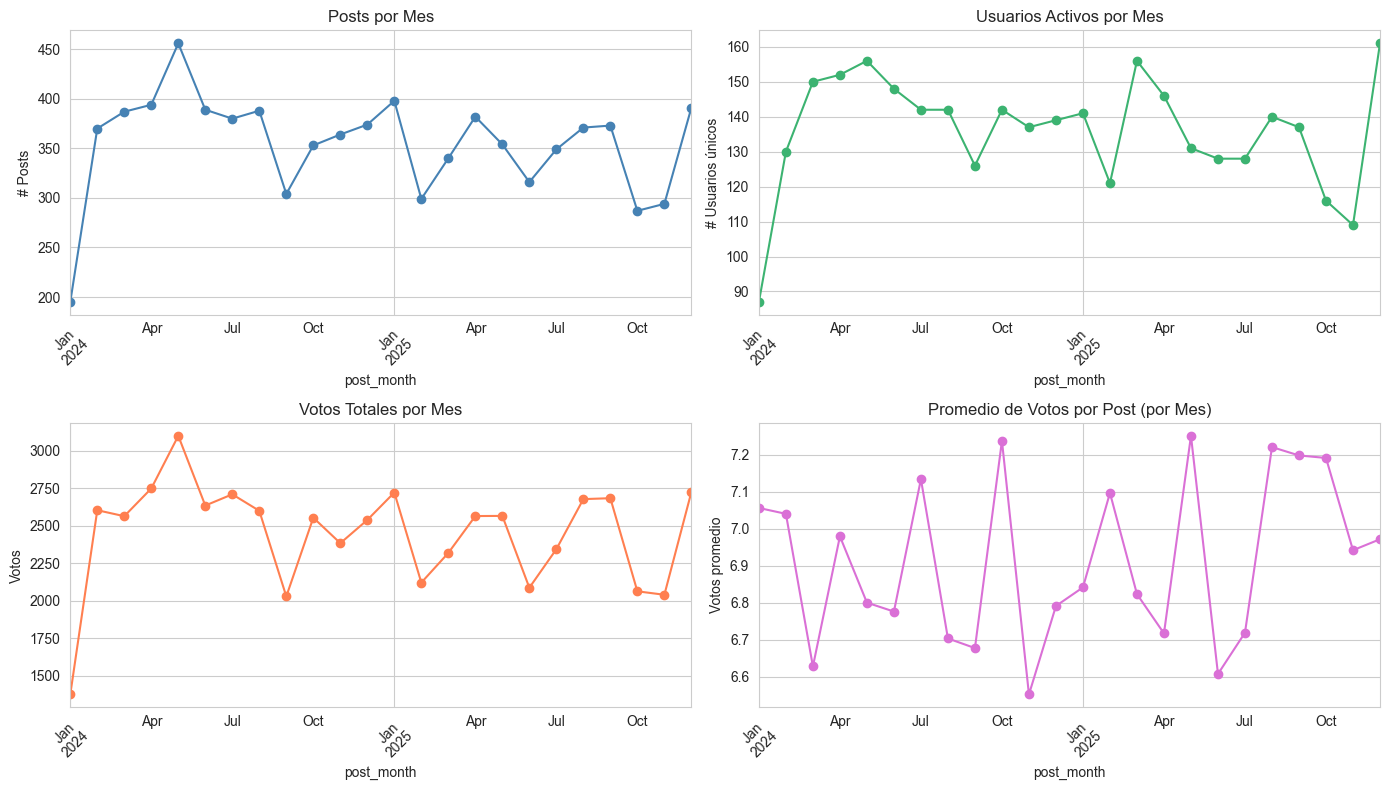

In [ ]:
# Tendencia temporal: convierte cada fecha a su mes 
df_clean['post_month'] = df_clean['post_created_at_dt'].dt.to_period('M')

# por cada mes calculo 4 metricas 
monthly = df_clean.groupby('post_month').agg(
    posts=('post_id', 'count'),
    total_votes=('votes_received', 'sum'),
    avg_votes=('votes_received', 'mean'),
    unique_users=('user_id', 'nunique')
)

fig, axes = plt.subplots(2, 2, figsize=(14, 8)) # tamaño de la tabla 
# grilla 2x2 

# axes[0,0] Posts por mes	
monthly['posts'].plot(ax=axes[0, 0], marker='o', color='steelblue')
axes[0, 0].set_title('Posts por Mes')
axes[0, 0].set_ylabel('# Posts')

# axes[0,1] Usuarios activos
monthly['unique_users'].plot(ax=axes[0, 1], marker='o', color='mediumseagreen')
axes[0, 1].set_title('Usuarios Activos por Mes')
axes[0, 1].set_ylabel('# Usuarios únicos')

# axes[1,0] Votos totales
monthly['total_votes'].plot(ax=axes[1, 0], marker='o', color='coral')
axes[1, 0].set_title('Votos Totales por Mes')
axes[1, 0].set_ylabel('Votos')

# axes[1,1] Promedio de votos
monthly['avg_votes'].plot(ax=axes[1, 1], marker='o', color='orchid')
axes[1, 1].set_title('Promedio de Votos por Post (por Mes)')
axes[1, 1].set_ylabel('Votos promedio')

for ax in axes.flat:
    ax.tick_params(axis='x', rotation=45) # roto al eje X 

plt.tight_layout()
plt.show() # muestro 

## Exportación de Archivos

In [ ]:
# Exportar datasets y métricas

# renombro las columnas a sus nombres originales  
rename_map = {
    'plan_type_clean': 'plan_type', 'post_category_clean': 'post_category',
    'device_type_clean': 'device_type', 'days_since_signup_calc': 'days_since_signup'
}

# selecciono las columnas que voy a importar 
export_cols = ['user_id', 'created_at', 'country', 'plan_type_clean', 'user_age',
               'post_id', 'post_category_clean', 'post_created_at', 'votes_received',
               'user_total_posts', 'days_since_signup_calc', 'device_type_clean']

# RENOMBRO EL CSV Y LO EXPORTO SIN LA COLUMNA DE INDECE DE PANDAS
df_clean[export_cols].rename(columns=rename_map).to_csv('clean_product_activity.csv', index=False)
print(f"clean_product_activity.csv: {len(df_clean)} filas")

# FILAS CON ERRORES   
q_cols = ['user_id', 'created_at', 'country', 'plan_type', 'user_age', 'post_id',
          'post_category', 'post_created_at', 'votes_received', 'user_total_posts',
          'days_since_signup', 'device_type', 'reason_code']
# EXPORTO
df_quarantine[q_cols].to_csv('quarantine_product_activity.csv', index=False)
print(f"quarantine_product_activity.csv: {len(df_quarantine)} filas")

# UN RESUMEN CON LAS METRICAS CLAVE DEL ANALISIS 
metrics = pd.DataFrame({ # creo un nuevo dataframe clave del analisis 
    'metric': ['total_raw_rows', 'duplicates_removed', 'quarantine_rows', 'core_rows',
               'unique_users', 'avg_votes_per_event', 'avg_votes_per_user',
               'median_votes', 'pct_posts_top1pct', 'pct_votes_top1pct'],
    # Cada valor corresponde a su métrica en orden, se exportan al CSV de resumen
    'value': [raw_rows, dupes_removed, len(df_quarantine), len(df_clean),
              n_users, round(avg_event, 2), round(avg_user, 2),
              df_clean['votes_received'].median(),
              round(pct_posts_top1, 1), round(pct_votes_top1, 1)]
})
# EXPORTO 
metrics.to_csv('metrics_summary.csv', index=False)
print(f"metrics_summary.csv: {len(metrics)} métricas")

clean_product_activity.csv: 8508 filas
quarantine_product_activity.csv: 102 filas
metrics_summary.csv: 10 métricas
